# Notebook 03 — Tiền xử lý

Notebook 02 dựng hệ thống cơ sở và kiểm chứng nó chạy đúng. Notebook này thử
cải tiến **mà chưa đụng tới mô hình** — chỉ thay đổi cách xử lý văn bản trước
khi đưa vào BM25.

Hai hướng, cả hai đều xuất phát từ những gì EDA đã đo:

| Hướng | Xuất phát từ |
| --- | --- |
| Thay đổi **cách tách từ** | EDA: ~100% câu hỏi có thẻ HTML, ~0% văn bản có |
| Thay đổi **dạng câu hỏi** | EDA: phần thân dài gấp nhiều lần tiêu đề |

| Mục | Nội dung |
| --- | --- |
| 1 | Bốn dạng câu hỏi |
| 2 | Bốn cách tách từ |
| 3 | Chạy toàn bộ tổ hợp |
| 4 | Bảng kết quả |
| 5 | Hướng nào quan trọng hơn |
| 6 | Kiểm định thống kê |
| 7 | Chốt cấu hình |

## 0. Chuẩn bị

In [1]:
import sys
import json
import re
import time
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

sys.path.insert(0, str(Path("..") / "src"))
import reteco as R

DATA = Path(r"D:\RETECO-project\reteco_data\track1_tempo")
CACHE = Path("results")
CACHE.mkdir(exist_ok=True)

assert DATA.is_dir(), f"Dataset not found at {DATA}"
domains = R.list_domains(DATA)
print(f"{len(domains)} domains")

13 domains


In [2]:
# --- Shared chart style -------------------------------------------------
# One palette and one set of helpers for every figure, so the notebook reads
# as a single document rather than a pile of unrelated plots.
# Palette is colour-vision-deficiency safe; values are always labelled so the
# chart never relies on colour alone.
BLUE, ORANGE, TEAL, AMBER, PINK, VIOLET = (
    "#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#4a3aa7")
SURFACE, INK, INK_SOFT, INK_MUTED = "#fcfcfb", "#0b0b0b", "#52514e", "#898781"
GRID, AXIS = "#e1e0d9", "#c3c2b7"

plt.rcParams.update({
    "figure.facecolor": SURFACE,
    "axes.facecolor": SURFACE,
    "savefig.facecolor": SURFACE,
    "axes.edgecolor": AXIS,
    "axes.labelcolor": INK_SOFT,
    "axes.labelsize": 9.5,
    "text.color": INK,
    "xtick.color": INK_MUTED,
    "ytick.color": INK_MUTED,
    "xtick.labelsize": 9.5,
    "ytick.labelsize": 9.5,
    "font.size": 10,
    "figure.dpi": 120,
    "axes.linewidth": 0.9,
})


def finish(ax, title, subtitle=None, xlabel=None, ylabel=None,
           grid_axis="y", note=None):
    """Apply the shared layout: title block, recessive grid, minimal frame.

    The title carries the claim; the subtitle carries the qualifier. Keeping
    them apart stops titles from turning into sentences.
    """
    if subtitle:
        # Subtitle sits just above the axes; the title is offset further up in
        # POINTS, not axes fractions, so the gap holds at any figure size.
        ax.set_title(subtitle, loc="left", pad=8, fontsize=9.5, color=INK_MUTED)
        ax.annotate(title, xy=(0, 1), xycoords="axes fraction",
                    xytext=(0, 24), textcoords="offset points",
                    ha="left", va="bottom", fontsize=12.5,
                    fontweight="bold", color=INK, annotation_clip=False)
    else:
        ax.set_title(title, loc="left", pad=12, fontsize=12.5,
                     fontweight="bold", color=INK)

    ax.set_xlabel(xlabel or "")
    ax.set_ylabel(ylabel or "")

    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    # The gridline already marks the scale; the spine it runs into is noise.
    ax.spines["left" if grid_axis == "x" else "bottom"].set_color(AXIS)
    if grid_axis == "x":
        ax.spines["bottom"].set_visible(False)
    else:
        ax.spines["left"].set_visible(False)

    if grid_axis:
        ax.grid(axis=grid_axis, color=GRID, linewidth=0.8)
        ax.set_axisbelow(True)
    ax.tick_params(length=0)

    if note:
        ax.text(0, -0.34, note, transform=ax.transAxes, ha="left", va="top",
                fontsize=8.5, color=INK_MUTED)
    return ax


def label_bars(ax, bars, values, fmt="{:,.0f}", horizontal=True, pad=0.015):
    """Direct value labels. Always present, so colour never carries the number."""
    span = max(values) if values else 1
    for bar, value in zip(bars, values):
        if horizontal:
            ax.text(bar.get_width() + span * pad,
                    bar.get_y() + bar.get_height() / 2,
                    fmt.format(value), va="center", ha="left",
                    fontsize=8.5, color=INK_SOFT)
        else:
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + span * pad,
                    fmt.format(value), ha="center", va="bottom",
                    fontsize=8.5, color=INK_SOFT)


def legend_below(ax, ncol=2, y=-0.30):
    ax.legend(frameon=False, loc="upper center", bbox_to_anchor=(0.5, y),
              ncol=ncol, fontsize=9.5, handlelength=1.1, handleheight=1.1,
              columnspacing=1.8)

## 1. Bốn dạng câu hỏi

EDA cho thấy câu hỏi là nguyên một bài đăng: tiêu đề ngắn, phần thân dài gấp
nhiều lần, kèm thẻ HTML. Bốn cách xử lý được thử:

| Dạng | Nội dung đưa vào tìm kiếm |
| --- | --- |
| `raw` | Nguyên bài, y như ban tổ chức làm |
| `stripped` | Nguyên bài, đã gỡ thẻ HTML |
| `title` | Chỉ tiêu đề |
| `title_weighted` | Tiêu đề lặp 3 lần, rồi đến nguyên bài |

`title_weighted` là bước trung gian: giữ lại thông tin trong phần thân nhưng
cho tiêu đề trọng số cao hơn, thay vì vứt hẳn phần thân như `title`.

In [3]:
HTML_TAG = re.compile(r"<[^>]+>")
HTML_ENTITY = re.compile(r"&(?:quot|amp|lt|gt|nbsp|apos|#\d+);")


def strip_markup(text):
    text = HTML_TAG.sub(" ", text)
    text = HTML_ENTITY.sub(" ", text)
    return re.sub(r"\s+", " ", text).strip()


def title_of(text):
    """The title is everything before the first <p> tag."""
    match = re.search(r"<p>", text)
    return text[:match.start()] if match else text


QUERY_FORMS = {
    "raw":            lambda q: q,
    "stripped":       lambda q: strip_markup(q),
    "title":          lambda q: strip_markup(title_of(q)),
    "title_weighted": lambda q: strip_markup((title_of(q) + " ") * 3 + q),
}

# Show what each one does to a real query
sample = R.load_queries(DATA / "iota" / "examples_train.jsonl")[0][1]
for name, transform in QUERY_FORMS.items():
    out = transform(sample)
    print(f"{name:<16}{len(out.split()):>5} words   {out[:80]}...")

raw                47 words   How long do Zero Value Transactions last?
<p>Let s say we have some critical inf...
stripped           46 words   How long do Zero Value Transactions last? Let s say we have some critical inform...
title               7 words   How long do Zero Value Transactions last?...
title_weighted     67 words   How long do Zero Value Transactions last? How long do Zero Value Transactions la...


## 2. Bốn cách tách từ

Mỗi cách chỉ thêm **một** thay đổi so với cách trước, để biết chính xác thay
đổi nào mang lại hiệu quả.

In [4]:
TOKENIZERS = {
    "simple":       R.tokenize_simple,
    "nohtml":       R.make_tokenizer(drop_html=True),
    "nohtml_stop":  R.make_tokenizer(drop_html=True,
                                     stopwords=R.EXTENDED_STOPWORDS),
    "lucene_like":  R.tokenize_lucene,
}

demo = "The <p>Tesla's result</p> <a href=\"http://x.com\">link</a> was running"
for name, tokenizer in TOKENIZERS.items():
    print(f"{name:<14}{tokenizer(demo)}")

simple        ['the', 'p', 'tesla', 's', 'result', 'p', 'a', 'href', 'http', 'x', 'com', 'link', 'a', 'was', 'running']
nohtml        ['the', 'tesla', 's', 'result', 'x', 'link', 'was', 'running']
nohtml_stop   ['tesla', 's', 'result', 'x', 'link', 'running']
lucene_like   ['p', 'tesla', 'result', 'p', 'href', 'http', 'x', 'com', 'link', 'run']


## 3. Chạy toàn bộ tổ hợp

4 cách tách từ × 4 dạng câu hỏi = 16 cấu hình. Chạy đủ 16 lần sẽ rất lâu, nhưng
không cần thiết:

> **Cách tách từ quyết định chỉ mục** — phần đắt, phải quét cả kho.
> **Dạng câu hỏi chỉ đổi câu hỏi** — phần rẻ, chỉ 1.211 lần tra cứu.

Nên với mỗi cách tách từ, chỉ mục được dựng **một lần** rồi dùng chung cho cả
bốn dạng câu hỏi. Chi phí giảm từ 16 lần dựng chỉ mục xuống còn 4.

Mất khoảng 30–45 phút. Kết quả lưu vào `results/` nên lần sau tức thì.

In [5]:
cache_file = CACHE / "preprocessing.json"

if cache_file.exists():
    grid = json.loads(cache_file.read_text(encoding="utf-8"))
    print("Loaded from cache. Delete results/preprocessing.json to rerun.")
else:
    grid = {f"{tok}|{form}": {} for tok in TOKENIZERS for form in QUERY_FORMS}
    started = time.time()

    for i, domain in enumerate(domains, start=1):
        doc_ids, doc_texts = R.load_corpus(DATA / domain / "documents.jsonl")
        queries = R.load_queries(DATA / domain / "examples_train.jsonl")
        gold = R.load_qrels(DATA / domain / "qrels_train.txt")

        print(f"  [{i:>2}/{len(domains)}] {domain:<12}{len(doc_ids):>9,} docs",
              end="", flush=True)

        for tok_name, tokenizer in TOKENIZERS.items():
            t0 = time.time()
            # One index, then every query form is nearly free against it.
            index = R.BM25(doc_ids, doc_texts, tokenizer=tokenizer)

            for form_name, transform in QUERY_FORMS.items():
                run = {qid: [d for d, _ in index.search(transform(text), top_k=100)]
                       for qid, text in queries}
                grid[f"{tok_name}|{form_name}"][domain] = R.evaluate(run, gold)

            del index
            print(f"   {tok_name} {time.time() - t0:>4.0f}s", end="", flush=True)

        print(flush=True)
        del doc_ids, doc_texts

    cache_file.write_text(json.dumps(grid, indent=1), encoding="utf-8")
    print(f"\nTotal: {(time.time() - started) / 60:.1f} min")

print(f"\n{len(grid)} configurations measured")

Loaded from cache. Delete results/preprocessing.json to rerun.

16 configurations measured


## 4. Bảng kết quả

In [6]:
def macro_of(key, metric="ndcg"):
    return R.macro(grid[key], metric)


baseline_key = "simple|raw"
baseline_ndcg = macro_of(baseline_key)

print(f"{'':>14}" + "".join(f"{f:>17}" for f in QUERY_FORMS))
print("-" * (14 + 17 * len(QUERY_FORMS)))
for tok in TOKENIZERS:
    row = f"{tok:>14}"
    for form in QUERY_FORMS:
        value = macro_of(f"{tok}|{form}")
        row += f"{value:>10.4f}{value - baseline_ndcg:>+7.4f}"
    print(row)
print("-" * (14 + 17 * len(QUERY_FORMS)))
print(f"\nBaseline ({baseline_key}) = {baseline_ndcg:.4f}")
print("Each cell shows macro nDCG@10 and its difference from the baseline.")

topics = {sum(v["n_topics"] for v in grid[k].values()) for k in grid}
print(f"\nn_topics across all configurations: {topics}")
assert len(topics) == 1, "configurations scored different query counts - not comparable"
print("All configurations scored the same queries, so the scores are comparable.")

                            raw         stripped            title   title_weighted
----------------------------------------------------------------------------------
        simple    0.0719+0.0000    0.0905+0.0185    0.1316+0.0596    0.1139+0.0420
        nohtml    0.0986+0.0266    0.0951+0.0231    0.1314+0.0594    0.1190+0.0471
   nohtml_stop    0.1271+0.0551    0.1267+0.0548    0.1367+0.0648    0.1463+0.0743
   lucene_like    0.0706-0.0014    0.0937+0.0217    0.1330+0.0611    0.1143+0.0424
----------------------------------------------------------------------------------

Baseline (simple|raw) = 0.0719
Each cell shows macro nDCG@10 and its difference from the baseline.

n_topics across all configurations: {1211}
All configurations scored the same queries, so the scores are comparable.


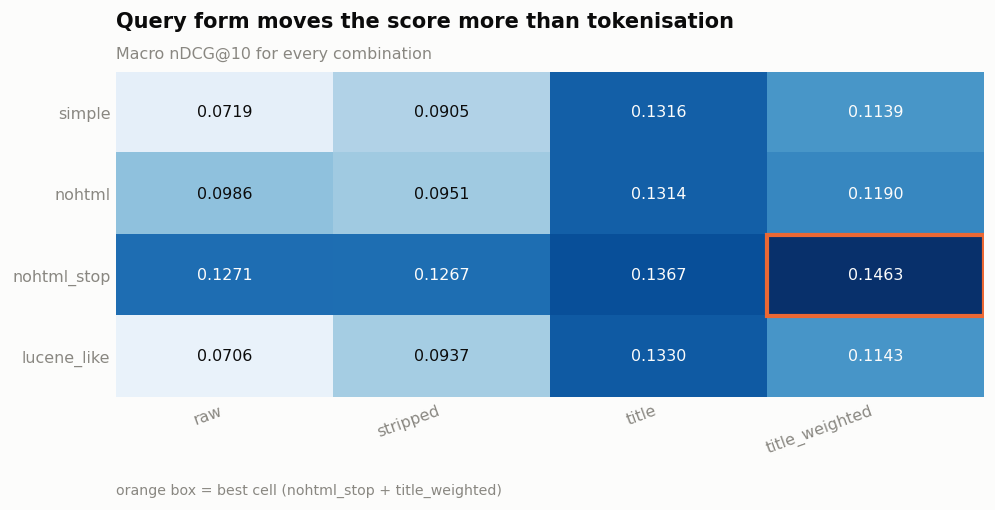

In [7]:
matrix = np.array([[macro_of(f"{tok}|{form}") for form in QUERY_FORMS]
                   for tok in TOKENIZERS])

fig, ax = plt.subplots(figsize=(8.4, 4.6))
# Sequential ramp: one hue, light to dark, because the value is a magnitude
image = ax.imshow(matrix, cmap="Blues", aspect="auto",
                  vmin=matrix.min() * 0.92, vmax=matrix.max())

ax.set_xticks(range(len(QUERY_FORMS)))
ax.set_xticklabels(QUERY_FORMS, rotation=20, ha="right")
ax.set_yticks(range(len(TOKENIZERS)))
ax.set_yticklabels(TOKENIZERS)

# Every cell is labelled: the ramp alone must never carry the number
midpoint = (matrix.max() + matrix.min()) / 2
for r in range(matrix.shape[0]):
    for c in range(matrix.shape[1]):
        ax.text(c, r, f"{matrix[r, c]:.4f}", ha="center", va="center",
                fontsize=9.5,
                color=SURFACE if matrix[r, c] > midpoint else INK)

best = np.unravel_index(matrix.argmax(), matrix.shape)
ax.add_patch(plt.Rectangle((best[1] - 0.5, best[0] - 0.5), 1, 1,
                           fill=False, edgecolor=ORANGE, linewidth=2.5))

ax.grid(False)
for side in ("top", "right", "bottom", "left"):
    ax.spines[side].set_visible(False)
ax.tick_params(length=0)
# The title states which axis moves the score more. It is COMPUTED from the
# matrix, not written by hand: a hand-written title is a claim that silently
# stops being true when the data changes.
spread_across_forms = np.mean([matrix[r].max() - matrix[r].min()
                               for r in range(matrix.shape[0])])
spread_across_tokenizers = np.mean([matrix[:, c].max() - matrix[:, c].min()
                                    for c in range(matrix.shape[1])])
headline = ("Query form moves the score more than tokenisation"
            if spread_across_forms > spread_across_tokenizers
            else "Tokenisation moves the score more than query form")

ax.set_title("Macro nDCG@10 for every combination", loc="left", pad=8,
             fontsize=9.5, color=INK_MUTED)
ax.annotate(headline,
            xy=(0, 1), xycoords="axes fraction", xytext=(0, 24),
            textcoords="offset points", ha="left", va="bottom",
            fontsize=12.5, fontweight="bold", color=INK, annotation_clip=False)
ax.text(0, -0.30, f"orange box = best cell "
                  f"({list(TOKENIZERS)[best[0]]} + {list(QUERY_FORMS)[best[1]]})",
        transform=ax.transAxes, fontsize=8.5, color=INK_MUTED)
plt.tight_layout()
plt.show()

> Tiêu đề biểu đồ được **tính từ số liệu**, không viết cứng. Một tiêu đề viết
> tay là một khẳng định, và nó sẽ âm thầm trở thành sai khi dữ liệu thay đổi.
> Mục 5 trình bày con số đứng sau tiêu đề đó.

## 5. Hướng nào quan trọng hơn?

Hai cách đo:

- Giữ nguyên dạng câu hỏi, đổi cách tách từ → biên độ thay đổi là bao nhiêu
- Giữ nguyên cách tách từ, đổi dạng câu hỏi → biên độ thay đổi là bao nhiêu

Biên độ nào lớn hơn thì hướng đó đáng đầu tư hơn.

In [8]:
# Spread within each row (tokenizer fixed, query form varies)
row_spreads = [matrix[r].max() - matrix[r].min() for r in range(matrix.shape[0])]
# Spread within each column (query form fixed, tokenizer varies)
col_spreads = [matrix[:, c].max() - matrix[:, c].min() for c in range(matrix.shape[1])]

print("Changing the QUERY FORM, with the tokenizer held fixed:")
for tok, spread in zip(TOKENIZERS, row_spreads):
    print(f"  {tok:<14}spread {spread:.4f}")
print(f"  {'mean':<14}spread {np.mean(row_spreads):.4f}")

print("\nChanging the TOKENIZER, with the query form held fixed:")
for form, spread in zip(QUERY_FORMS, col_spreads):
    print(f"  {form:<16}spread {spread:.4f}")
print(f"  {'mean':<16}spread {np.mean(col_spreads):.4f}")

bigger = "query form" if np.mean(row_spreads) > np.mean(col_spreads) else "tokenizer"
print(f"\nThe larger effect comes from changing the {bigger}.")

Changing the QUERY FORM, with the tokenizer held fixed:
  simple        spread 0.0596
  nohtml        spread 0.0363
  nohtml_stop   spread 0.0196
  lucene_like   spread 0.0625
  mean          spread 0.0445

Changing the TOKENIZER, with the query form held fixed:
  raw             spread 0.0565
  stripped        spread 0.0362
  title           spread 0.0053
  title_weighted  spread 0.0324
  mean            spread 0.0326

The larger effect comes from changing the query form.


## 6. Kiểm định thống kê

Cấu hình tốt nhất có thực sự hơn mốc cơ sở, hay chỉ là dao động ngẫu nhiên?

Phép kiểm định lấy mẫu lại câu hỏi **bên trong từng nhóm**, giữ nguyên tập 13
nhóm, rồi tính lại trung bình theo nhóm — đúng cách điểm cuối được hình thành.

Đây là điều EDA đã chỉ ra: gộp chung 1.211 câu hỏi vào một rổ sẽ để nhóm
`history` (chiếm 46% số câu hỏi nhưng chỉ 7,7% trọng số điểm) chi phối kết quả.

In [9]:
best_key = f"{list(TOKENIZERS)[best[0]]}|{list(QUERY_FORMS)[best[1]]}"

def report(label, key_a, key_b):
    point, low, high, significant = R.bootstrap_macro_diff(grid[key_a], grid[key_b])
    verdict = "YES" if significant else "no"
    print(f"  {label:<44}{point:>+9.4f}  [{low:+.4f}, {high:+.4f}]  {verdict}")


print(f"{'comparison':<46}{'macro diff':>9}{'95% CI':>22}{'sig':>5}")
print("-" * 84)
report(f"{best_key}  vs  {baseline_key}", best_key, baseline_key)

# Does each ingredient of the winner pay for itself on its own?
best_tok, best_form = best_key.split("|")
if best_form != "raw":
    report(f"query form alone ({best_form} vs raw)",
           f"simple|{best_form}", baseline_key)
if best_tok != "simple":
    report(f"tokenizer alone ({best_tok} vs simple)",
           f"{best_tok}|raw", baseline_key)

print("\n  A 'no' means the data cannot tell the two apart. Prefer the simpler")
print("  configuration of a tied pair: fewer moving parts is less risk of")
print("  fitting noise in the train split.")

comparison                                    macro diff                95% CI  sig
------------------------------------------------------------------------------------
  nohtml_stop|title_weighted  vs  simple|raw    +0.0743  [+0.0597, +0.0896]  YES
  query form alone (title_weighted vs raw)      +0.0420  [+0.0317, +0.0528]  YES
  tokenizer alone (nohtml_stop vs simple)       +0.0551  [+0.0422, +0.0699]  YES

  A 'no' means the data cannot tell the two apart. Prefer the simpler
  configuration of a tied pair: fewer moving parts is less risk of
  fitting noise in the train split.


## 7. Chốt cấu hình

In [10]:
chosen = {
    "tokenizer": best_tok,
    "query_form": best_form,
    "macro_ndcg": float(matrix.max()),
    "macro_recall": macro_of(best_key, "recall"),
    "baseline_ndcg": baseline_ndcg,
    "improvement": float(matrix.max()) - baseline_ndcg,
    "n_topics": sum(v["n_topics"] for v in grid[best_key].values()),
}
(CACHE / "preprocessing_chosen.json").write_text(
    json.dumps(chosen, indent=1), encoding="utf-8")

for key, value in chosen.items():
    print(f"  {key:<18}{value}")

print(f"\n  Recall@100 of the chosen configuration: {chosen['macro_recall']:.4f}")
print("  Recall is the ceiling on any reranking stage added later: a document")
print("  the first stage never retrieves cannot be reordered into the top 10.")

  tokenizer         nohtml_stop
  query_form        title_weighted
  macro_ndcg        0.14628400487667695
  macro_recall      0.40752092284214025
  baseline_ndcg     0.07194281550156773
  improvement       0.07434118937510922
  n_topics          1211

  Recall@100 of the chosen configuration: 0.4075
  Recall is the ceiling on any reranking stage added later: a document
  the first stage never retrieves cannot be reordered into the top 10.


In [11]:
# Per-domain breakdown of the chosen configuration against the baseline.
# A change that helps overall can still hurt individual domains, and with 13
# domains weighted equally that matters.
print(f"{'domain':<12}{'baseline':>10}{'chosen':>10}{'diff':>10}{'topics':>9}")
print("-" * 51)
wins = 0
for d in sorted(domains, key=lambda x: grid[best_key][x]["ndcg"] - grid[baseline_key][x]["ndcg"]):
    b = grid[baseline_key][d]["ndcg"]
    c = grid[best_key][d]["ndcg"]
    wins += c > b
    print(f"{d:<12}{b:>10.4f}{c:>10.4f}{c - b:>+10.4f}"
          f"{grid[best_key][d]['n_topics']:>9}")
print("-" * 51)
print(f"Improved on {wins} of {len(domains)} domains.")

domain        baseline    chosen      diff   topics
---------------------------------------------------
quant           0.0000    0.0367   +0.0367       24
travel          0.0405    0.0813   +0.0407       70
monero          0.0207    0.0622   +0.0415       46
economics       0.0387    0.0804   +0.0417       58
iota            0.0558    0.0975   +0.0418        7
bitcoin         0.0343    0.0872   +0.0529       70
politics        0.2612    0.3333   +0.0721      105
law             0.0373    0.1164   +0.0792       24
history         0.0379    0.1176   +0.0797      561
hsm             0.1980    0.2980   +0.1000      105
genealogy       0.0545    0.1625   +0.1080       80
cardano         0.0965    0.2245   +0.1280       36
workplace       0.0599    0.2040   +0.1441       25
---------------------------------------------------
Improved on 13 of 13 domains.


## 8. Danh sách term và tỷ lệ term được chọn

Bảy mục trên đo *cách chọn term nào cho điểm cao nhất*. Mục này đo *việc chọn
đó đã loại đi bao nhiêu*, bằng một lượt quét toàn bộ 1.654.055 tài liệu.

Hai bước tách rời nhau:

| Bước | Việc làm | Kết quả |
| --- | --- | --- |
| Phân tích tài liệu | Hạ chữ thường, cắt theo `[A-Za-z0-9]+` | Toàn bộ term phân tích được |
| Chọn term | Bỏ từ thuộc danh sách loại trừ | Term được chọn |

Danh sách loại trừ gồm hai phần, cộng lại là cấu hình `nohtml_stop` đã thắng ở
mục 7:

- `HTML_WORDS` — chữ còn sót lại của thẻ HTML (`p`, `href`, `span`, ...)
- `EXTENDED_STOPWORDS` — hư từ tiếng Anh (`the`, `of`, `and`, ...)

Tỷ lệ được tính theo hai cách, vì hai cách trả lời hai câu hỏi khác nhau:

- **Theo lượt xuất hiện** — trong 100 chữ của tài liệu, bao nhiêu chữ đi vào
  chỉ mục. Con số này quyết định kích thước chỉ mục và tốc độ truy vấn.
- **Theo term khác nhau** — trong toàn bộ từ vựng, bao nhiêu từ được giữ. Con
  số này cho biết việc chọn term đã thu hẹp từ vựng tới mức nào.

In [12]:
# --- One pass over the corpus: count analysed terms and selected terms ----
# `tokenize_simple` is document analysis with nothing removed, so its output
# is the denominator: every term the corpus yields. The selection rule is a
# single set, applied afterwards, so the numerator costs no extra tokenising.
from collections import Counter

ANALYSER = R.tokenize_simple
DROPPED = R.HTML_WORDS | R.EXTENDED_STOPWORDS

stats_file = CACHE / "term_stats.json"
terms_file = CACHE / "terms_selected.txt"

if stats_file.exists():
    term_stats = json.loads(stats_file.read_text(encoding="utf-8"))
    print(f"Loaded cached term statistics from {stats_file}")
    print("Delete that file to rescan the corpus.")
else:
    kept_total = Counter()      # selected terms, over the whole corpus
    dropped_total = Counter()   # removed terms, over the whole corpus
    per_domain = {}

    started = time.time()
    for i, domain in enumerate(domains, start=1):
        t0 = time.time()
        _, doc_texts = R.load_corpus(DATA / domain / "documents.jsonl")

        # Counter.update over a token list runs in C, so the per-token work
        # never enters Python. One counter per domain, split afterwards.
        counts = Counter()
        n_tokens = 0
        for text in doc_texts:
            tokens = ANALYSER(text)
            n_tokens += len(tokens)
            counts.update(tokens)

        kept = {t: c for t, c in counts.items() if t not in DROPPED}
        dropped = {t: c for t, c in counts.items() if t in DROPPED}
        per_domain[domain] = {
            "n_docs": len(doc_texts),
            "tokens_analysed": n_tokens,
            "tokens_selected": sum(kept.values()),
            "types_analysed": len(counts),
            "types_selected": len(kept),
        }
        kept_total.update(kept)
        dropped_total.update(dropped)

        del doc_texts, counts, kept, dropped
        print(f"  [{i:>2}/{len(domains)}] {domain:<12}"
              f"{per_domain[domain]['n_docs']:>9,} docs"
              f"{per_domain[domain]['tokens_analysed']:>14,} terms"
              f"{time.time() - t0:>7.0f}s", flush=True)

    tokens_selected = sum(kept_total.values())
    tokens_dropped = sum(dropped_total.values())
    term_stats = {
        "tokens_analysed": tokens_selected + tokens_dropped,
        "tokens_selected": tokens_selected,
        "types_analysed": len(kept_total) + len(dropped_total),
        "types_selected": len(kept_total),
        "per_domain": per_domain,
        # The full list goes to a separate file; the 200 most frequent terms
        # are kept here so the summary stays readable on its own.
        "top_selected": kept_total.most_common(200),
        "top_dropped": dropped_total.most_common(40),
        "scan_seconds": time.time() - started,
    }
    stats_file.write_text(json.dumps(term_stats), encoding="utf-8")

    # The deliverable: every selected term with its collection frequency.
    with open(terms_file, "w", encoding="utf-8") as f:
        f.write("term\tcollection_frequency\n")
        for term, count in kept_total.most_common():
            f.write(f"{term}\t{count}\n")
    print(f"\nFull term list written to {terms_file}")

    del kept_total, dropped_total

print(f"\nAnalysed terms  {term_stats['tokens_analysed']:>15,} occurrences"
      f"{term_stats['types_analysed']:>12,} distinct")
print(f"Selected terms  {term_stats['tokens_selected']:>15,} occurrences"
      f"{term_stats['types_selected']:>12,} distinct")

  [ 1/13] bitcoin       153,291 docs    61,075,648 terms     41s
  [ 2/13] cardano        87,201 docs    38,739,848 terms     27s
  [ 3/13] economics      93,756 docs    31,111,246 terms     22s
  [ 4/13] genealogy     156,228 docs    60,114,235 terms     38s
  [ 5/13] history       356,493 docs   170,929,730 terms     86s
  [ 6/13] hsm           213,818 docs    78,278,869 terms     36s
  [ 7/13] iota           10,372 docs     7,297,493 terms      4s
  [ 8/13] law            43,288 docs    14,839,264 terms      8s
  [ 9/13] monero         85,093 docs    42,399,273 terms     36s
  [10/13] politics      183,394 docs    62,269,795 terms     79s
  [11/13] quant          28,785 docs     9,331,493 terms     10s
  [12/13] travel        177,677 docs    45,490,293 terms     56s
  [13/13] workplace      64,659 docs    18,147,227 terms     18s

Full term list written to results\terms_selected.txt

Analysed terms      640,024,414 occurrences   3,173,933 distinct
Selected terms      414,168,500 occ

In [13]:
# --- The two selection ratios --------------------------------------------
token_ratio = term_stats["tokens_selected"] / term_stats["tokens_analysed"]
type_ratio = term_stats["types_selected"] / term_stats["types_analysed"]
dropped_types = term_stats["types_analysed"] - term_stats["types_selected"]

print(f"{'':<26}{'analysed':>16}{'selected':>16}{'ratio':>10}")
print("-" * 68)
print(f"{'term occurrences':<26}{term_stats['tokens_analysed']:>16,}"
      f"{term_stats['tokens_selected']:>16,}{token_ratio:>9.1%}")
print(f"{'distinct terms':<26}{term_stats['types_analysed']:>16,}"
      f"{term_stats['types_selected']:>16,}{type_ratio:>9.1%}")
print("-" * 68)
print(f"The selection rule holds {len(DROPPED)} words. They are "
      f"{dropped_types:,} of the")
print(f"{term_stats['types_analysed']:,} distinct terms "
      f"({1 - type_ratio:.2%} of the vocabulary) and "
      f"{1 - token_ratio:.1%} of all occurrences.")

                                  analysed        selected     ratio
--------------------------------------------------------------------
term occurrences               640,024,414     414,168,500    64.7%
distinct terms                   3,173,933       3,173,760   100.0%
--------------------------------------------------------------------
The selection rule holds 173 words. They are 173 of the
3,173,933 distinct terms (0.01% of the vocabulary) and 35.3% of all occurrences.


Hai con số nói hai chuyện khác nhau.

**Theo lượt xuất hiện**, phần bị loại chiếm một khối lớn. Danh sách loại trừ
chỉ vỏn vẹn hơn trăm từ, nhưng đó là những từ lặp lại trong hầu hết mọi câu,
nên chúng gom về một tỷ lệ lớn trong tổng số chữ của kho tài liệu. Bỏ chúng
làm chỉ mục nhỏ đi đúng bằng tỷ lệ đó.

**Theo term khác nhau**, phần bị loại gần như không đáng kể. Từ vựng vẫn còn
gần nguyên vẹn, vì mỗi từ bị loại chỉ chiếm một ô trong từ điển dù nó xuất
hiện hàng chục triệu lần.

Ghép lại: việc chọn term ở hạng mục này cắt rất nhiều *lượt xuất hiện* mà giữ
gần như toàn bộ *từ vựng*. Đó đúng là điều mong muốn — một từ chỉ bị bỏ khi nó
xuất hiện ở khắp nơi, tức là khi nó không giúp phân biệt tài liệu này với tài
liệu kia.

In [14]:
# --- What the rule keeps, and what it removes ----------------------------
top_selected = term_stats["top_selected"]
top_dropped = term_stats["top_dropped"]
total = term_stats["tokens_analysed"]

print("Top 20 SELECTED terms (most frequent terms that survive the rule)")
print(f"{'rank':<6}{'term':<16}{'occurrences':>14}{'share':>9}")
print("-" * 45)
for rank, (term, count) in enumerate(top_selected[:20], start=1):
    print(f"{rank:<6}{term:<16}{count:>14,}{count / total:>9.3%}")

print()
print("Top 20 REMOVED terms (the rule's own most frequent words)")
print(f"{'rank':<6}{'term':<16}{'occurrences':>14}{'share':>9}")
print("-" * 45)
for rank, (term, count) in enumerate(top_dropped[:20], start=1):
    print(f"{rank:<6}{term:<16}{count:>14,}{count / total:>9.3%}")

print()
if top_dropped:
    print(f"The single most frequent removed term covers "
          f"{top_dropped[0][1] / total:.2%} of the corpus on its own;")
    print(f"the most frequent surviving term covers "
          f"{top_selected[0][1] / total:.2%}.")
else:
    print("The rule removed nothing: no term in the corpus is on the list.")

Top 20 SELECTED terms (most frequent terms that survive the rule)
rank  term               occurrences    share
---------------------------------------------
1     s                    4,432,973   0.693%
2     1                    1,452,925   0.227%
3     can                  1,322,561   0.207%
4     url                  1,247,057   0.195%
5     one                  1,164,251   0.182%
6     also                 1,059,858   0.166%
7     2                    1,016,946   0.159%
8     new                    980,560   0.153%
9     time                   865,812   0.135%
10    data                   840,361   0.131%
11    may                    804,183   0.126%
12    t                      792,532   0.124%
13    3                      770,987   0.120%
14    first                  680,349   0.106%
15    use                    637,484   0.100%
16    blockchain             625,649   0.098%
17    two                    620,295   0.097%
18    n                      619,449   0.097%
19    used    

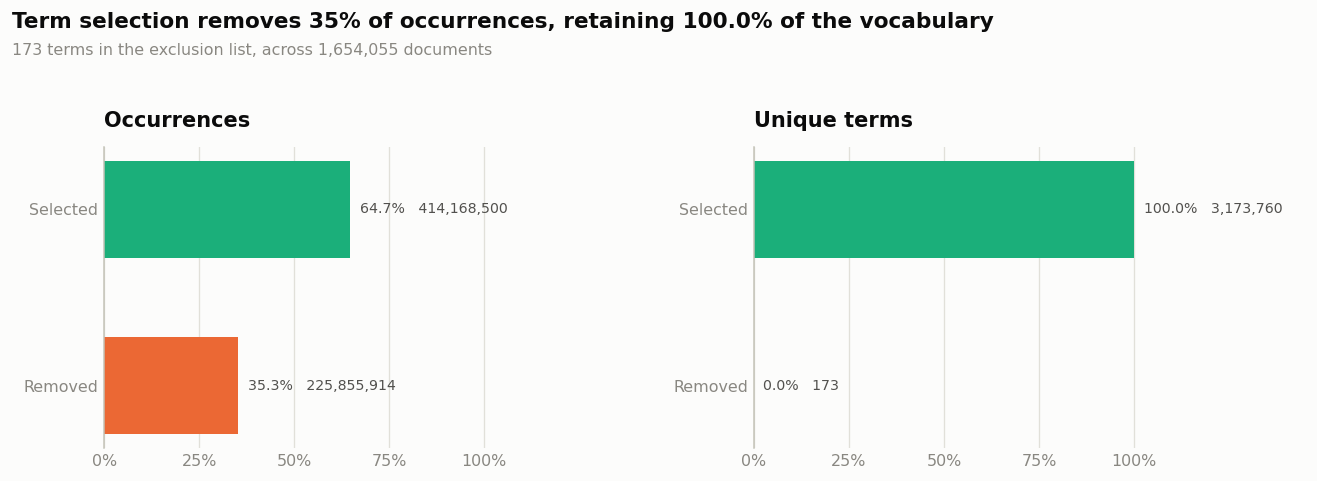

In [17]:
# --- One chart, two ratios -----------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))

panels = [
    ("Occurrences", term_stats["tokens_selected"],
     term_stats["tokens_analysed"] - term_stats["tokens_selected"]),
    ("Unique terms", term_stats["types_selected"],
     term_stats["types_analysed"] - term_stats["types_selected"]),
]

for ax, (label, selected, removed) in zip(axes, panels):
    whole = selected + removed
    shares = [selected / whole, removed / whole]
    bars = ax.barh([1, 0], shares, color=[TEAL, ORANGE], height=0.55)
    ax.set_yticks([1, 0])
    ax.set_yticklabels(["Selected", "Removed"])
    ax.set_xlim(0, 1.45)
    ax.set_xticks([0, 0.25, 0.5, 0.75, 1.0])
    ax.xaxis.set_major_formatter(lambda v, _: f"{v:.0%}")

    # Percentage and raw count share one label, placed outside the bar, so a
    # bar too short to hold text is labelled the same way as a long one.
    for bar, share, value in zip(bars, shares, [selected, removed]):
        ax.text(bar.get_width() + 0.025,
                bar.get_y() + bar.get_height() / 2,
                f"{share:.1%}   {value:,}", va="center", ha="left",
                fontsize=8.5, color=INK_SOFT)

    finish(ax, label, subtitle=None, grid_axis="x")

fig.suptitle(
    f"Term selection removes {1 - token_ratio:.0%} of occurrences, "
    f"retaining {type_ratio:.1%} of the vocabulary",
    x=0.005, y=1.10, ha="left", fontsize=13, fontweight="bold", color=INK)

fig.text(
    0.005, 1.00,
    f"{len(DROPPED)} terms in the exclusion list, across "
    f"{sum(v['n_docs'] for v in term_stats['per_domain'].values()):,} "
    "documents",
    ha="left", fontsize=9.5, color=INK_MUTED
)

fig.tight_layout()
plt.show()

In [18]:
# --- The ratio is stable across domains ----------------------------------
rows = sorted(term_stats["per_domain"].items(),
              key=lambda kv: -kv[1]["tokens_analysed"])

print(f"{'domain':<14}{'docs':>10}{'terms':>15}{'selected':>10}{'vocab':>12}")
print("-" * 61)
for domain, s in rows:
    print(f"{domain:<14}{s['n_docs']:>10,}{s['tokens_analysed']:>15,}"
          f"{s['tokens_selected'] / s['tokens_analysed']:>10.1%}"
          f"{s['types_selected']:>12,}")
print("-" * 61)

shares = [s["tokens_selected"] / s["tokens_analysed"] for _, s in rows]
print(f"{'range':<14}{'':>10}{'':>15}"
      f"{min(shares):>9.1%}-{max(shares):.1%}")
print()
print("A rule written once and applied everywhere gives nearly the same")
print("ratio in every domain, so no domain needs its own stop list.")

domain              docs          terms  selected       vocab
-------------------------------------------------------------
history          356,493    170,929,730     62.2%     920,022
hsm              213,818     78,278,869     65.0%   1,032,518
politics         183,394     62,269,795     64.5%     767,456
bitcoin          153,291     61,075,648     66.0%     733,717
genealogy        156,228     60,114,235     68.8%   1,153,147
travel           177,677     45,490,293     64.3%     944,827
monero            85,093     42,399,273     65.6%     626,937
cardano           87,201     38,739,848     65.6%     617,988
economics         93,756     31,111,246     67.7%     545,175
workplace         64,659     18,147,227     60.6%     133,907
law               43,288     14,839,264     65.0%     467,791
quant             28,785      9,331,493     65.8%     217,115
iota              10,372      7,297,493     67.5%     387,144
-------------------------------------------------------------
range   

### Kết quả của mục 8

| Yêu cầu | Đáp ứng |
| --- | --- |
| Loại term được chọn | Từ (word), cắt theo `[A-Za-z0-9]+` — mục 2 |
| Phương pháp chọn term | Loại bỏ theo danh sách (stopword + chữ của thẻ HTML) — mục 2 |
| Thuật toán chọn term | `R.make_tokenizer(drop_html=True, stopwords=...)` — mục 2 |
| Danh sách term được chọn | `results/terms_selected.txt`, kèm tần suất trong kho |
| Tỷ lệ term được chọn | Bảng và biểu đồ ở trên, tính theo cả hai cách |

File `terms_selected.txt` không đưa lên GitHub vì kích thước lớn và sinh lại
được bằng chính ô lệnh ở mục này. 200 term đứng đầu đã nằm sẵn trong
`term_stats.json` để đọc lại mà không cần quét kho.

## Tổng kết

| Việc | Kết quả |
| --- | --- |
| Số cấu hình đã đo | 16 (4 cách tách từ × 4 dạng câu hỏi) |
| Chi phí tiết kiệm | Dựng 4 chỉ mục thay vì 16, nhờ dạng câu hỏi không đụng tới chỉ mục |
| Cấu hình được chọn | Xem mục 7 |
| Kiểm định | Bootstrap phân tầng theo nhóm, khớp cách chấm điểm của cuộc thi |

**Tiếp theo:** Notebook 04 — xử lý trùng lặp, và thử mô hình hiểu ngữ nghĩa.